In [ ]:
# pip install opencv-python tensorflow matplotlib seaborn scikit-learn pandas numpy plotly
# pip install kaggle

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("Environment Setup Check:")
print("=" * 50)
print("TensorFlow Version:", tf.__version__)
print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

Environment Setup Check:
TensorFlow Version: 2.20.0
OpenCV Version: 4.13.0
NumPy Version: 2.2.6
Pandas Version: 2.3.2


In [ ]:
# Dataset

dataset_path = fr'A:\Data Science\LLM\NEU-DET\NEU-DET\train\images'

image_extensions = ['*.jpg', '*.jpeg', '*.png',]
image_paths = []
for ext in image_extensions:
    image_paths.extend(glob.glob(f'{dataset_path}/**/{ext}', recursive=True))
    image_paths.extend(glob.glob(f'{dataset_path}/{ext}', recursive=True))

print("=" * 20)
print("Dataset Exploration")
print("=" * 20)

print(f"\nTotal images found: {len(image_paths)}")
# print(image_paths)

Dataset Exploration

Total images found: 1440
['A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_1.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_10.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_100.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_101.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_102.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_103.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_104.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_105.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_106.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_107.jpg', 'A:\\Data Science\\LLM\\NEU-DET\\NEU-DET\\train\\images\\crazing\\crazing_108.jpg', 'A:\\Data Science\\LLM\\NEU-DET\

In [ ]:
# DataFrame with paths and labels

defect_classes = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
print("Defect classes:", defect_classes)

data = []
paths=fr'A:\Data Science\LLM\NEU-DET\NEU-DET\train\images'
for cls in defect_classes:
    class_path = fr"{paths}\{cls}"
    # print(class_path)
    if os.path.exists(class_path):
        class_images = glob.glob(f'{class_path}/*.jpg') + glob.glob(f'{class_path}/*.png')
        for img_path in class_images:
            data.append({'image_path': img_path, 'label': cls})
        # print(f"  {cls}: {len(class_images)} images")
        # print(data)

df = pd.DataFrame(data)
print(f"\nTotal images in DataFrame: {len(df)}")

print("\nClass distribution:")
print(df['label'].value_counts())

Defect classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Total images in DataFrame: 1440

Class distribution:
label
crazing            240
inclusion          240
patches            240
pitted_surface     240
rolled-in_scale    240
scratches          240
Name: count, dtype: int64


In [ ]:
# Cell 6: Multiple random images with Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pick 6 random images (one per class)
random_samples = df.groupby('label').sample(1).reset_index()
print(random_samples)
# Create 2x3 grid
fig = make_subplots(rows=2, cols=3,
                    subplot_titles=random_samples['label'].tolist())

# Add all images at once (still no loop in the visualization part)
positions = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3)]

for idx, (_, row) in enumerate(random_samples.iterrows()):

    img = plt.imread(row['image_path'])
    r, c = positions[idx]
    fig.add_trace(go.Image(z=img), row=r, col=c)
    fig.update_xaxes(showticklabels=False, showgrid=False, row=r, col=c)
    fig.update_yaxes(showticklabels=False, showgrid=False, row=r, col=c)

fig.update_layout(height=800, width=1000,
                    title_text="Random Samples from Each Class")
fig.show()

   index                                         image_path            label
0     26  A:\Data Science\LLM\NEU-DET\NEU-DET\train\imag...          crazing
1    320  A:\Data Science\LLM\NEU-DET\NEU-DET\train\imag...        inclusion
2    616  A:\Data Science\LLM\NEU-DET\NEU-DET\train\imag...          patches
3    797  A:\Data Science\LLM\NEU-DET\NEU-DET\train\imag...   pitted_surface
4   1069  A:\Data Science\LLM\NEU-DET\NEU-DET\train\imag...  rolled-in_scale
5   1410  A:\Data Science\LLM\NEU-DET\NEU-DET\train\imag...        scratches


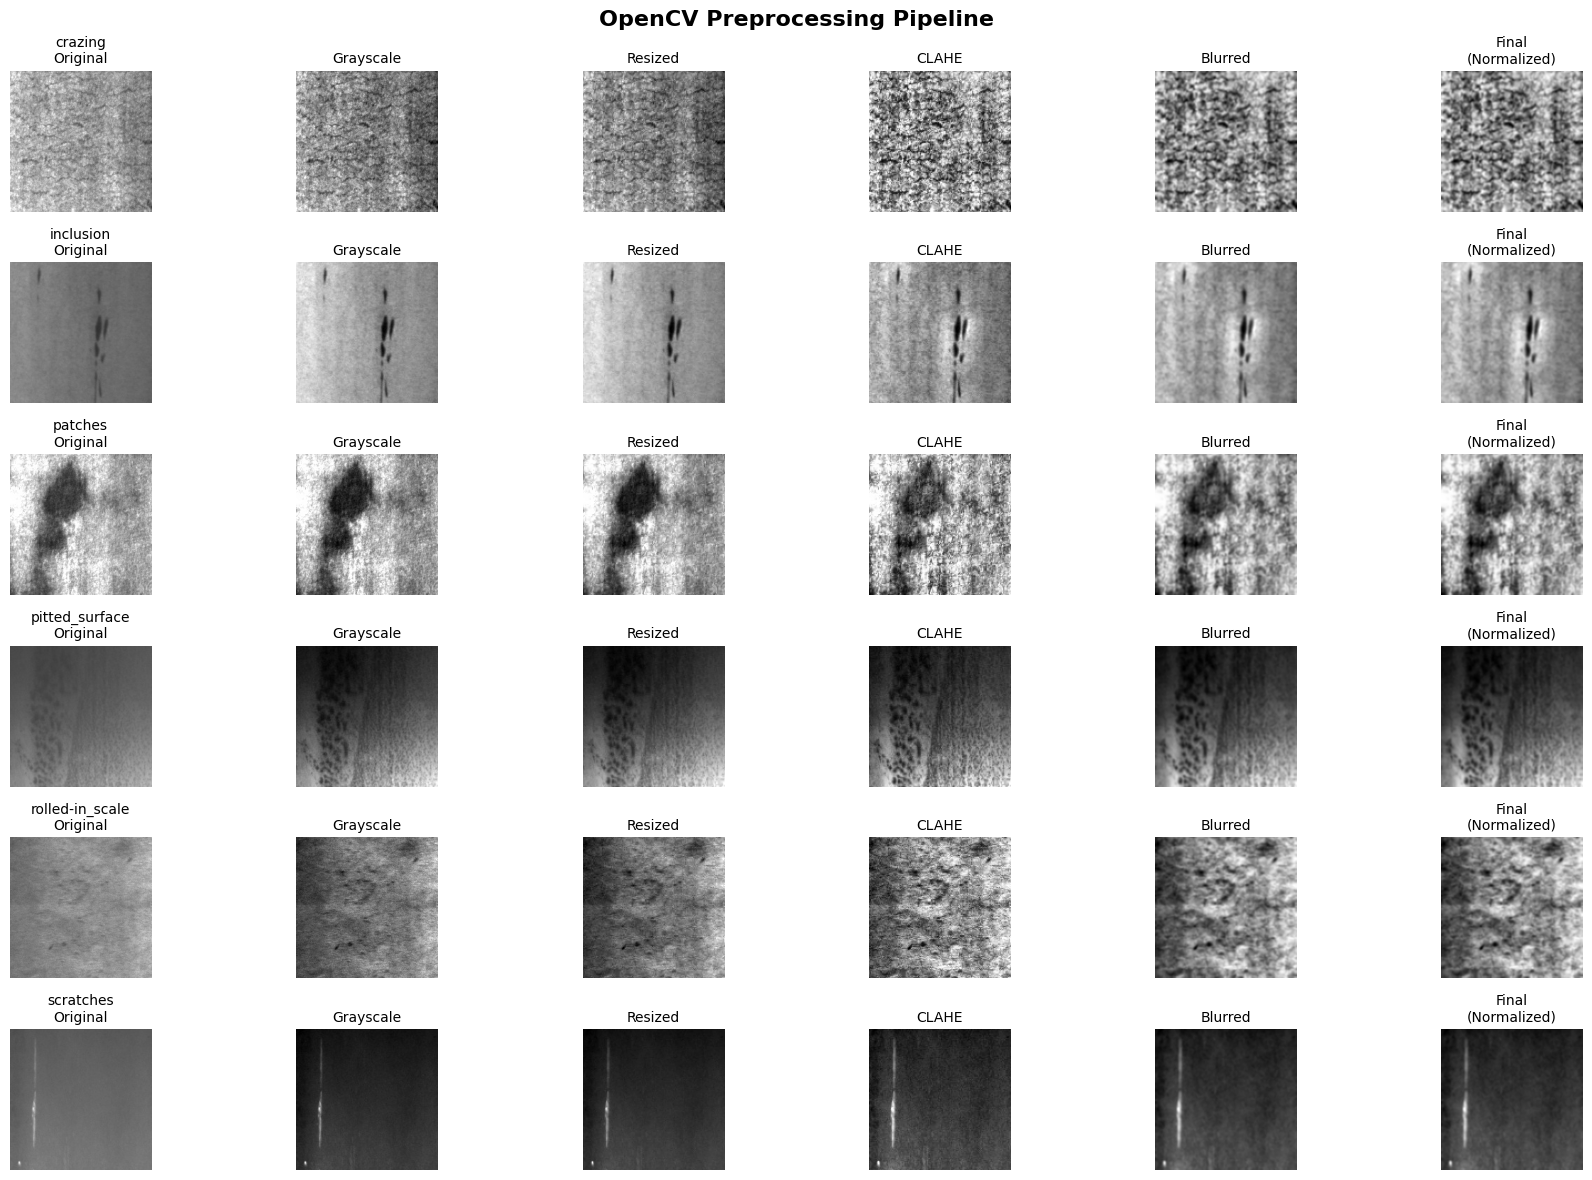

In [ ]:
# Preprocessing pipeline
def preprocess_image(image_path, target_size=(128, 128), visualize=False):

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    steps = {}

    img_resized = cv2.resize(img_gray, target_size)
    if visualize:
        steps['resized'] = img_resized.copy()

    # Contrast Limited Adaptive Histogram Equalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_resized)
    if visualize:
        steps['clahe'] = img_clahe.copy()

    # Gaussian blur
    img_blurred = cv2.GaussianBlur(img_clahe, (3,3), 0)
    if visualize:
        steps['blurred'] = img_blurred.copy()

    # Normalize to [0,1]
    img_normalized = img_blurred.astype('float32') / 255.0

    # for CNN input
    img_final = np.expand_dims(img_normalized, axis=-1)

    if visualize:
        steps['original_color'] = img_rgb
        steps['original_gray'] = img_gray
        steps['final'] = img_final
        return steps
    else:
        return img_final

fig, axes = plt.subplots(len(defect_classes), 6, figsize=(18, 12))

for row, cls in enumerate(defect_classes):

    sample_path = df[df['label'] == cls]['image_path'].iloc[0]
    steps = preprocess_image(sample_path,visualize=True)

    axes[row, 0].imshow(steps['original_color'])
    axes[row, 0].set_title(f'{cls}\nOriginal', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(steps['original_gray'], cmap='gray')
    axes[row, 1].set_title('Grayscale', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(steps['resized'], cmap='gray')
    axes[row, 2].set_title('Resized', fontsize=10)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(steps['clahe'], cmap='gray')
    axes[row, 3].set_title('CLAHE', fontsize=10)
    axes[row, 3].axis('off')

    axes[row, 4].imshow(steps['blurred'], cmap='gray')
    axes[row, 4].set_title('Blurred', fontsize=10)
    axes[row, 4].axis('off')

    axes[row, 5].imshow(steps['final'].squeeze(), cmap='gray')
    axes[row, 5].set_title('Final\n(Normalized)', fontsize=10)
    axes[row, 5].axis('off')

plt.suptitle('OpenCV Preprocessing Pipeline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(fr'preprocessing_pipeline1.png', dpi=700, bbox_inches='tight')
plt.show()

Training: 70% (aprx 1,008 images) - for model learning <br>
Validation: 15% (aprx 216 images) - for tuning hyperparameters <br>
Test: 15% (aprx 216 images) - for final evaluation (unseen data)

In [ ]:
# Load for training

X = [] # Image
y = [] # Label

# Load all images
total_images = len(df)
for i, row in df.iterrows():
    if i % 100 == 0:
        print(f"  Progress: {i}/{total_images} images processed")

    img = preprocess_image(row['image_path'])
    X.append(img)
    y.append(row['label'])

# Convert to numpy arrays
X = np.array(X)
print(f"\nX shape: {X.shape}")
print(f"Number of samples: {len(y)}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(y_categorical)
print(f"\nClass mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i}: {cls}")

# Split data (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print(f"\nDataset splits:")
print(f"  Training set: {X_train.shape}")
print(f"  Validation set: {X_val.shape}")
print(f"  Test set: {X_test.shape}")

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


  Progress: 0/1440 images processed
  Progress: 100/1440 images processed
  Progress: 200/1440 images processed
  Progress: 300/1440 images processed
  Progress: 400/1440 images processed
  Progress: 500/1440 images processed
  Progress: 600/1440 images processed
  Progress: 700/1440 images processed
  Progress: 800/1440 images processed
  Progress: 900/1440 images processed
  Progress: 1000/1440 images processed
  Progress: 1100/1440 images processed
  Progress: 1200/1440 images processed
  Progress: 1300/1440 images processed
  Progress: 1400/1440 images processed

X shape: (1440, 128, 128, 1)
Number of samples: 1440
[[1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]]

Class mapping:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches

Dataset splits:
  Training set: (1008, 128, 128, 1)
  Validation set: (216, 128, 128, 1)
  Test set: (216, 128, 128, 1)


In [ ]:
# Build CNN architecture
def create_cnn_model(input_shape=(128, 128, 1), num_classes=6):

    model = models.Sequential([
        # First conv block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Second conv block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Third conv block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fourth conv block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),

        # Dense layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model



input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

model = create_cnn_model(input_shape=input_shape, num_classes=num_classes)
model.summary()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel compiled successfully!")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,443,046 (5.50 MB)

 Trainable params: 1,439,590 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)


Model compiled successfully!


In [ ]:
# Train the CNN model
if 'model' in locals() and 'X_train' in locals():

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=15,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),

        ModelCheckpoint(
            fr'A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1,
            cooldown=2
        )
    ]

    # Train the model
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=50,
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )

    model.save(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\models\final_cnn_model2.h5')
    print(fr"\nModels saved to A:\Data Science\LLM\NEU-DET\NEU-DET\models\models")

    import pickle
    with open(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\results\training_history2.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    print("Training history saved")

else:
    print("Cannot train: Model or data not available")

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5250 - loss: 1.3618 - precision_3: 0.5662 - recall_3: 0.4131
Epoch 1: val_accuracy improved from None to 0.16667, saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5



Epoch 1: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6339 - loss: 1.1013 - precision_3: 0.6828 - recall_3: 0.5615 - val_accuracy: 0.1667 - val_loss: 4.5716 - val_precision_3: 0.1667 - val_recall_3: 0.1667 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7797 - loss: 0.6702 - precision_3: 0.7931 - recall_3: 0.7423
Epoch 2: val_accuracy did not improve from 0.16667
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7857 - loss: 0.7042 - precision_3: 0.8057 - recall_3: 0.7569 - val_accuracy: 0.1667 - val_loss: 8.8341 - val_precision_3: 0.1667 - val_recall_3: 0.1667 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7901 - loss: 0.6859 - precision_3: 0.8125 - recall_3: 0.7635
Epoch 3: val_accuracy did not improve from 0.16667
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7808 - loss: 0.6656 - precision_3: 0.8061 


Epoch 15: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9345 - loss: 0.2152 - precision_3: 0.9396 - recall_3: 0.9266 - val_accuracy: 0.2731 - val_loss: 4.1104 - val_precision_3: 0.2143 - val_recall_3: 0.1528 - learning_rate: 5.0000e-04
Epoch 16/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9425 - loss: 0.1465 - precision_3: 0.9475 - recall_3: 0.9354
Epoch 16: val_accuracy did not improve from 0.27315
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9444 - loss: 0.1656 - precision_3: 0.9516 - recall_3: 0.9365 - val_accuracy: 0.2454 - val_loss: 4.2488 - val_precision_3: 0.2512 - val_recall_3: 0.2407 - learning_rate: 5.0000e-04
Epoch 17/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9424 - loss: 0.1748 - precision_3: 0.9531 - recall_3: 0.9379
Epoch 17: val_accuracy improved from 0.27315 to 0.54167, saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5


Epoch 17: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9464 - loss: 0.1627 - precision_3: 0.9537 - recall_3: 0.9395 - val_accuracy: 0.5417 - val_loss: 2.9572 - val_precision_3: 0.5604 - val_recall_3: 0.5370 - learning_rate: 5.0000e-04
Epoch 18/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9325 - loss: 0.2023 - precision_3: 0.9337 - recall_3: 0.9321
Epoch 18: val_accuracy did not improve from 0.54167
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9395 - loss: 0.1813 - precision_3: 0.9422 - recall_3: 0.9375 - val_accuracy: 0.3935 - val_loss: 3.3296 - val_precision_3: 0.4009 - val_recall_3: 0.3935 - learning_rate: 5.0000e-04
Epoch 19/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9529 - loss: 0.1526 - precision_3: 0.9569 - recall_3: 0.9514
Epoch 19: val_accuracy did not improve from 0.54167
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9395 - loss: 0.1734 - precisi


Epoch 20: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9593 - loss: 0.1334 - precision_3: 0.9658 - recall_3: 0.9534 - val_accuracy: 0.6667 - val_loss: 1.2747 - val_precision_3: 0.6878 - val_recall_3: 0.6528 - learning_rate: 5.0000e-04
Epoch 21/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9481 - loss: 0.1606 - precision_3: 0.9533 - recall_3: 0.9473
Epoch 21: val_accuracy improved from 0.66667 to 0.92593, saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5


...


Epoch 24: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9683 - loss: 0.1115 - precision_3: 0.9690 - recall_3: 0.9623 - val_accuracy: 0.9537 - val_loss: 0.0937 - val_precision_3: 0.9537 - val_recall_3: 0.9537 - learning_rate: 5.0000e-04
Epoch 25/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9585 - loss: 0.1052 - precision_3: 0.9621 - recall_3: 0.9522
Epoch 25: val_accuracy improved from 0.95370 to 0.98148, saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5



Epoch 25: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9544 - loss: 0.1155 - precision_3: 0.9589 - recall_3: 0.9484 - val_accuracy: 0.9815 - val_loss: 0.0551 - val_precision_3: 0.9860 - val_recall_3: 0.9769 - learning_rate: 5.0000e-04
Epoch 26/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9538 - loss: 0.1489 - precision_3: 0.9546 - recall_3: 0.9530
Epoch 26: val_accuracy did not improve from 0.98148
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9593 - loss: 0.1238 - precision_3: 0.9612 - recall_3: 0.9573 - val_accuracy: 0.9815 - val_loss: 0.0704 - val_precision_3: 0.9860 - val_recall_3: 0.9815 - learning_rate: 5.0000e-04
Epoch 27/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9520 - loss: 0.1525 - precision_3: 0.9591 - recall_3: 0.9512
Epoch 27: val_accuracy did not improve from 0.98148
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9405 - loss: 0.1633 - precisi


Epoch 34: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9742 - loss: 0.0895 - precision_3: 0.9761 - recall_3: 0.9712 - val_accuracy: 0.9907 - val_loss: 0.0314 - val_precision_3: 0.9953 - val_recall_3: 0.9861 - learning_rate: 2.5000e-04
Epoch 35/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9723 - loss: 0.0733 - precision_3: 0.9736 - recall_3: 0.9715
Epoch 35: val_accuracy did not improve from 0.99074
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9752 - loss: 0.0663 - precision_3: 0.9771 - recall_3: 0.9742 - val_accuracy: 0.9259 - val_loss: 0.1643 - val_precision_3: 0.9346 - val_recall_3: 0.9259 - learning_rate: 2.5000e-04
Epoch 36/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9744 - loss: 0.0624 - precision_3: 0.9793 - recall_3: 0.9716
Epoch 36: val_accuracy did not improve from 0.99074
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9722 - loss: 0.0785 - precisi


Epoch 42: finished saving model to A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9762 - loss: 0.0708 - precision_3: 0.9771 - recall_3: 0.9752 - val_accuracy: 0.9954 - val_loss: 0.0330 - val_precision_3: 0.9953 - val_recall_3: 0.9907 - learning_rate: 1.2500e-04
Epoch 43/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9808 - loss: 0.0615 - precision_3: 0.9815 - recall_3: 0.9778
Epoch 43: val_accuracy did not improve from 0.99537
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9841 - loss: 0.0505 - precision_3: 0.9851 - recall_3: 0.9831 - val_accuracy: 0.9861 - val_loss: 0.0380 - val_precision_3: 0.9907 - val_recall_3: 0.9861 - learning_rate: 1.2500e-04
Epoch 44/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9754 - loss: 0.0807 - precision_3: 0.9780 - recall_3: 0.9744
Epoch 44: val_accuracy did not improve from 0.99537
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9752 - loss: 0.0782 - precisi

\nModels saved to A:\Data Science\LLM\NEU-DET\NEU-DET\models\models
Training history saved


In [ ]:
# Cell 13: Load and analyze saved training history
import pickle
import numpy as np

history_path = fr'A:\Data Science\LLM\NEU-DET\NEU-DET\results\training_history2.pkl'

try:
    with open(history_path, 'rb') as f:
        history_data = pickle.load(f)

    print("=" * 25)
    print("Training History Analysis")
    print("=" * 25)
    print(f"File: {history_path}")
    print(f"\nMetrics available: {list(history_data.keys())}")
    print(f"Total epochs: {len(history_data['loss'])}")

    # Best epoch
    best_epoch = np.argmin(history_data['val_loss'])
    print(f"\nBest Model (Epoch {best_epoch + 1}):")
    print(f"  Train Loss: {history_data['loss'][best_epoch]:.4f}")
    print(f"  Val Loss: {history_data['val_loss'][best_epoch]:.4f}")
    print(f"  Train Accuracy: {history_data['accuracy'][best_epoch]:.4f}")
    print(f"  Val Accuracy: {history_data['val_accuracy'][best_epoch]:.4f}")

    # Precision if available
    if 'precision' in history_data:
        print(f"  Train Precision: {history_data['precision_3'][best_epoch]:.4f}")
        print(f"  Val Precision: {history_data['val_precision_3'][best_epoch]:.4f}")

    # Recall if available
    if 'recall' in history_data:
        print(f"  Train Recall: {history_data['recall_3'][best_epoch]:.4f}")
        print(f"  Val Recall: {history_data['val_recall_3'][best_epoch]:.4f}")


    # Summary table with all metrics
    print(f"\nSummary Table:")
    print("-" * 70)
    print(f"{'Metric':<20} {'Start':<10} {'Best':<10} {'End':<10} {'Improvement':<10}")
    print("-" * 70)

    metrics_to_show = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

    # Add precision if available
    if 'precision_3' in history_data:
        metrics_to_show.extend(['precision_3', 'val_precision_3'])
    if 'recall_3' in history_data:
        metrics_to_show.extend(['recall_3', 'val_recall_3'])

    for metric in metrics_to_show:
        if metric in history_data:
            start = history_data[metric][0]
            best = np.min(history_data[metric]) if 'loss' in metric else np.max(history_data[metric])
            end = history_data[metric][-1]
            improvement = (start - end) if 'loss' in metric else (end - start)
            print(f"{metric:<20} {start:<10.4f} {best:<10.4f} {end:<10.4f} {improvement:<10.4f}")

except FileNotFoundError:
    print(f"Error: File not found - {history_path}")
except Exception as e:
    print(f"Error loading file: {e}")

Training History Analysis
File: A:\Data Science\LLM\NEU-DET\NEU-DET\results\training_history2.pkl

Metrics available: ['accuracy', 'loss', 'precision_3', 'recall_3', 'val_accuracy', 'val_loss', 'val_precision_3', 'val_recall_3', 'learning_rate']
Total epochs: 49

Best Model (Epoch 34):
  Train Loss: 0.0895
  Val Loss: 0.0314
  Train Accuracy: 0.9742
  Val Accuracy: 0.9907

Summary Table:
----------------------------------------------------------------------
Metric               Start      Best       End        Improvement
----------------------------------------------------------------------
loss                 1.1013     0.0475     0.0587     1.0426    
val_loss             4.5716     0.0314     0.1381     4.4335    
accuracy             0.6339     0.9841     0.9831     0.3492    
val_accuracy         0.1667     0.9954     0.9537     0.7870    
precision_3          0.6828     0.9890     0.9841     0.3013    
val_precision_3      0.1667     0.9953     0.9537     0.7870    
recall_3   

Early Stopping Diagnostic
Best validation loss: 0.0314 at epoch 34
Final validation loss: 0.1381


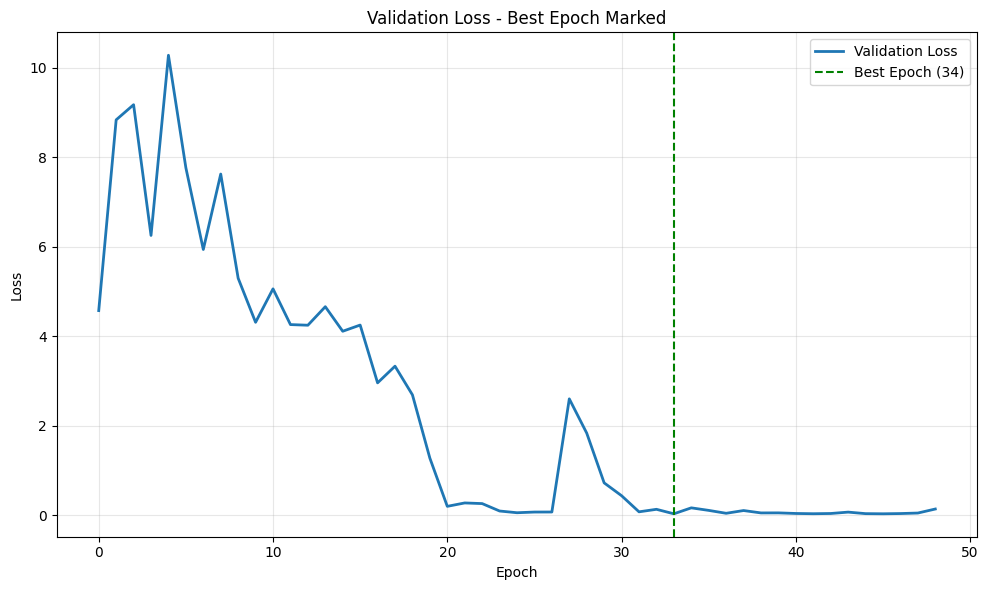

In [ ]:
# Diagnosing
if 'history' in locals():
    print("=" * 30)
    print("Early Stopping Diagnostic")
    print("=" * 30)

    best_epoch = np.argmin(history.history['val_loss'])
    best_loss = history.history['val_loss'][best_epoch]

    print(f"Best validation loss: {best_loss:.4f} at epoch {best_epoch + 1}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Epoch ({best_epoch + 1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Loss - Best Epoch Marked')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\results\early_stopping_diagnostic.png')
    plt.show()

Training History Visualization


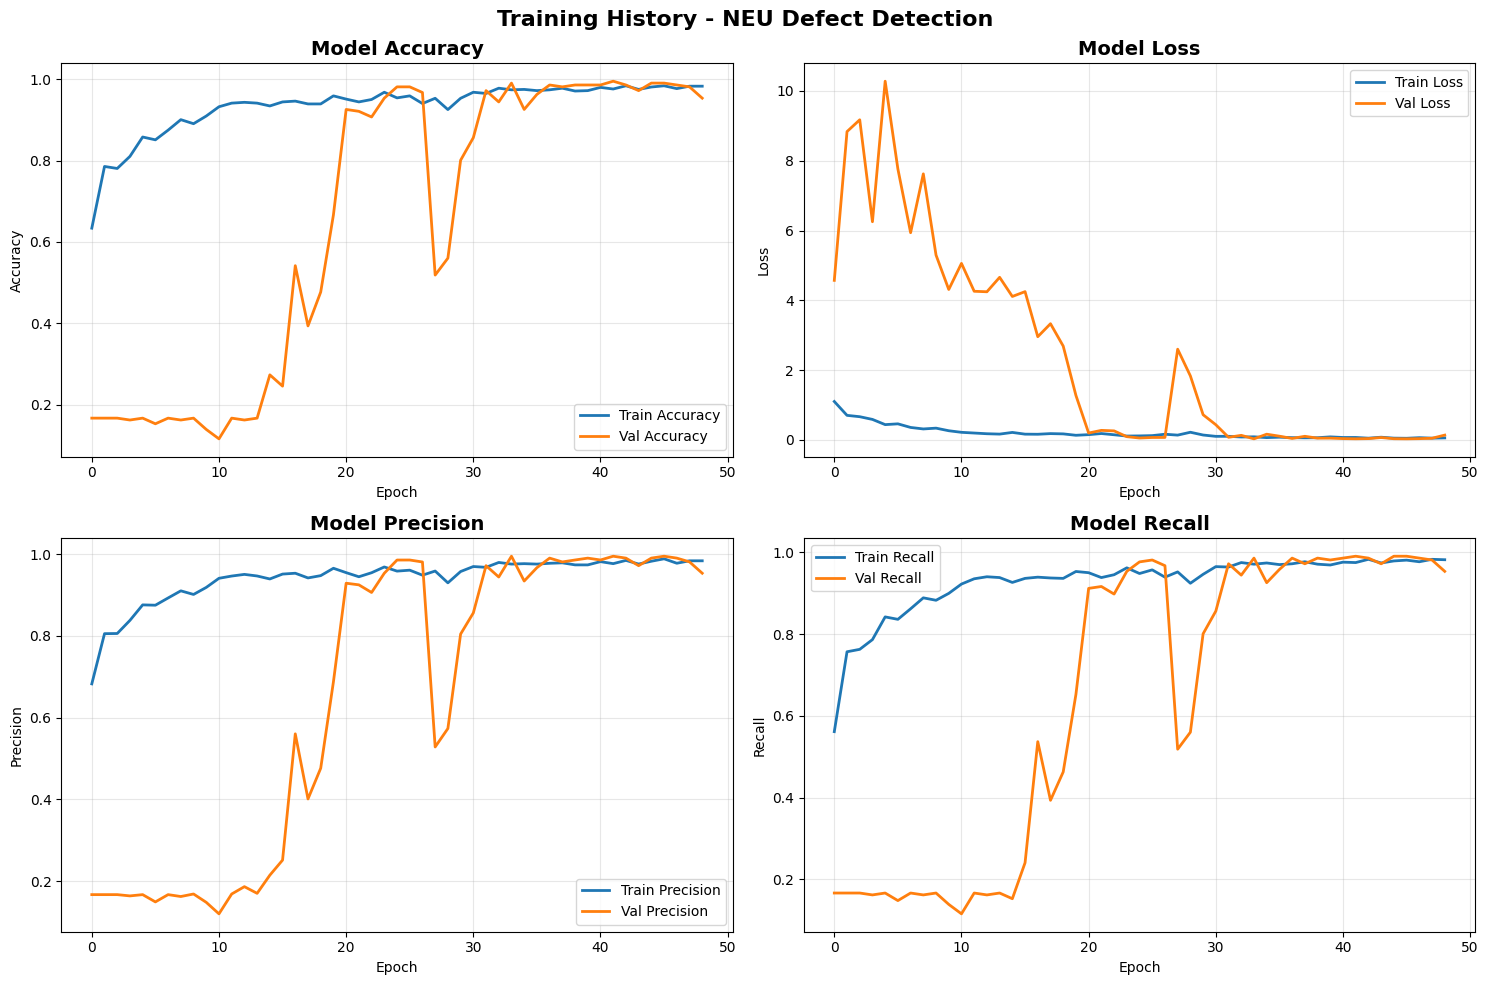


Best Model (Epoch 34):
  Train Accuracy: 0.9742
  Validation Accuracy: 0.9907
  Train Loss: 0.0895
  Validation Loss: 0.0314


In [ ]:
# Visualize training history
if 'history' in locals():
    print("=" * 50)
    print("Training History Visualization")
    print("=" * 50)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Precision
    if 'precision_3' in history.history:
        axes[1, 0].plot(history.history['precision_3'], label='Train Precision', linewidth=2)
        axes[1, 0].plot(history.history['val_precision_3'], label='Val Precision', linewidth=2)
        axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

    # Recall
    if 'recall_3' in history.history:
        axes[1, 1].plot(history.history['recall_3'], label='Train Recall', linewidth=2)
        axes[1, 1].plot(history.history['val_recall_3'], label='Val Recall', linewidth=2)
        axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Training History - NEU Defect Detection', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\results\training_history_detailed.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print best values
    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\nBest Model (Epoch {best_epoch + 1}):")
    print(f"  Train Accuracy: {history.history['accuracy'][best_epoch]:.4f}")
    print(f"  Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
    print(f"  Train Loss: {history.history['loss'][best_epoch]:.4f}")
    print(f"  Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")
else:
    print("No training history found")

Model Evaluation on Test Set


Best model loaded successfully

Generating predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step

Overall Performance Metrics:
  Accuracy:  0.9861 (98.61%)
  Precision: 0.9867
  Recall:    0.9861
  F1-Score:  0.9861

Per-Class Performance:
                 precision    recall  f1-score   support

        crazing     0.9474    1.0000    0.9730        36
      inclusion     0.9730    1.0000    0.9863        36
        patches     1.0000    0.9444    0.9714        36
 pitted_surface     1.0000    0.9722    0.9859        36
rolled-in_scale     1.0000    1.0000    1.0000        36
      scratches     1.0000    1.0000    1.0000        36

       accuracy                         0.9861       216
      macro avg     0.9867    0.9861    0.9861       216
   weighted avg     0.9867    0.9861    0.9861       216



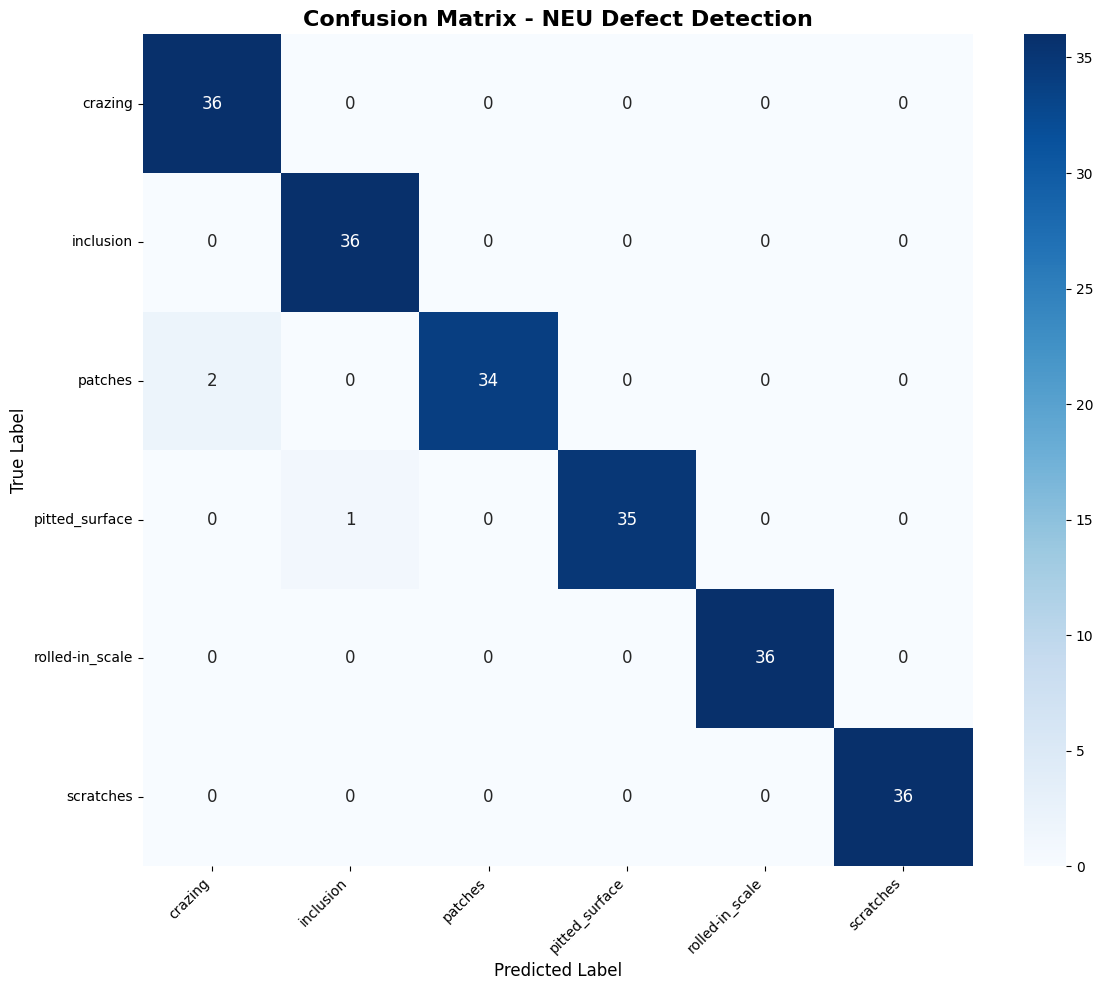


Per-Class Accuracy:
  crazing: 100.00%
  inclusion: 100.00%
  patches: 94.44%
  pitted_surface: 97.22%
  rolled-in_scale: 100.00%
  scratches: 100.00%


In [ ]:
# Comprehensive model evaluation
from tensorflow.keras.models import load_model

print("=" * 30)
print("Model Evaluation on Test Set")
print("=" * 30)

# Load best model
if os.path.exists(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5'):
    best_model = load_model(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\models\best_cnn_model2.h5')
    print("Best model loaded successfully")

    # Predict on test set
    print("\nGenerating predictions...")
    y_pred_probs = best_model.predict(X_test, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("\nOverall Performance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    # Classification report
    print("\nPer-Class Performance:")
    print(classification_report(y_true, y_pred,
                              target_names=label_encoder.classes_,
                              digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                annot_kws={'size': 12})
    plt.title('Confusion Matrix - NEU Defect Detection', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\results\confusion_matrix_detailed2.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Calculate per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-Class Accuracy:")
    for i, cls in enumerate(label_encoder.classes_):
        print(f"  {cls}: {class_accuracy[i]:.2%}")
else:
    print("Best model not found. Please complete training first.")

Misclassification Analysis
Total misclassifications: 3 out of 216 (1.39%)


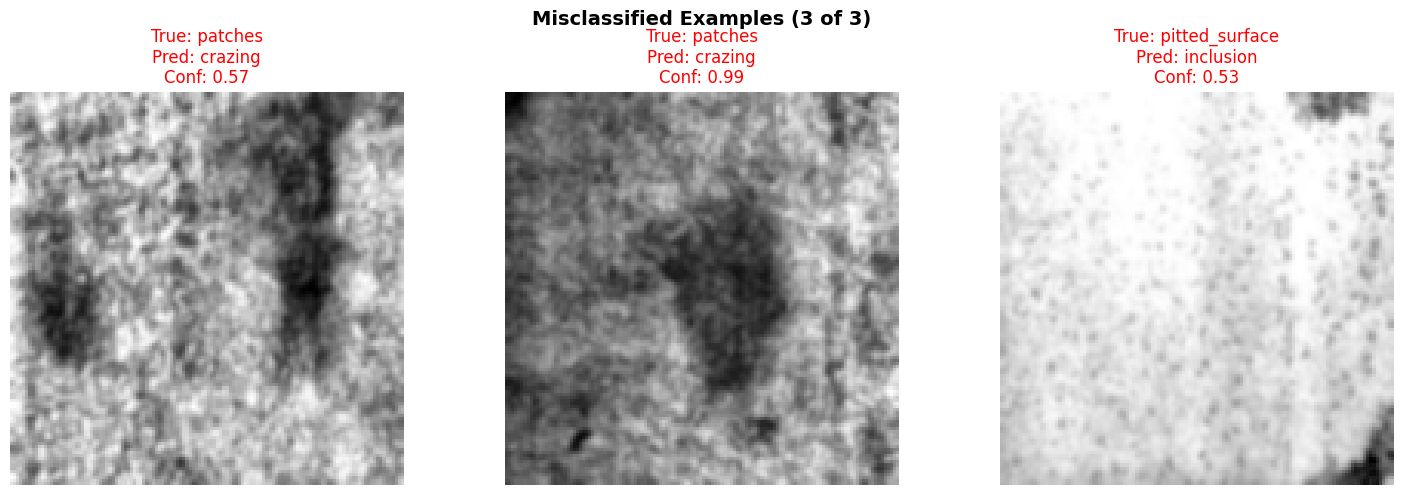

In [ ]:
# Misclassified images
if 'y_pred' in locals() and 'y_true' in locals():
    print("=" * 30)
    print("Misclassification Analysis")
    print("=" * 30)

    misclassified_indices = np.where(y_pred != y_true)[0]
    total_mis = len(misclassified_indices)
    total_samples = len(y_true)

    print(f"Total misclassifications: {total_mis} out of {total_samples} ({total_mis/total_samples*100:.2f}%)")

    if total_mis > 0:
        n_samples = min(3, total_mis)
        fig, axes = plt.subplots(1, n_samples, figsize=(15, 5))

        if n_samples == 1:
            axes = [axes]

        for i in range(n_samples):
            idx = misclassified_indices[i]
            img = X_test[idx].squeeze()

            # Get predictions
            true_class = label_encoder.classes_[y_true[idx]]
            pred_class = label_encoder.classes_[y_pred[idx]]
            confidence = y_pred_probs[idx][y_pred[idx]]

            # Display
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f'True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}',
                            fontsize=12, color='red')
            axes[i].axis('off')

        plt.suptitle(f'Misclassified Examples ({n_samples} of {total_mis})', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(fr'A:\Data Science\LLM\NEU-DET\NEU-DET\results\misclassified_examples.png', dpi=550, bbox_inches='tight')
        plt.show()
    else:
        print("Perfect classification! No misclassifications found!")
else:
    print("No predictions found. Please evaluate the model first.")